In [1]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

c:\Users\janva\DataEngineeringRoadMap\DataGeneration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Pobieranie danych
path = kagglehub.dataset_download("vipullrathod/fish-market")
print("Path to dataset files:", path)
print(os.listdir(path))

csv_path = os.path.join(path, "Fish.csv")
df = pd.read_csv(csv_path)

Path to dataset files: C:\Users\janva\.cache\kagglehub\datasets\vipullrathod\fish-market\versions\1
['Fish.csv']


  Species  Weight  Length1  Length2  Length3   Height   Width
0   Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1   Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2   Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
3   Bream   363.0     26.3     29.0     33.5  12.7300  4.4555
4   Bream   430.0     26.5     29.0     34.0  12.4440  5.1340
            Weight     Length1     Length2     Length3      Height       Width
count   159.000000  159.000000  159.000000  159.000000  159.000000  159.000000
mean    398.326415   26.247170   28.415723   31.227044    8.970994    4.417486
std     357.978317    9.996441   10.716328   11.610246    4.286208    1.685804
min       0.000000    7.500000    8.400000    8.800000    1.728400    1.047600
25%     120.000000   19.050000   21.000000   23.150000    5.944800    3.385650
50%     273.000000   25.200000   27.300000   29.400000    7.786000    4.248500
75%     650.000000   32.700000   35.500000   39.650000   12.365900    5.584

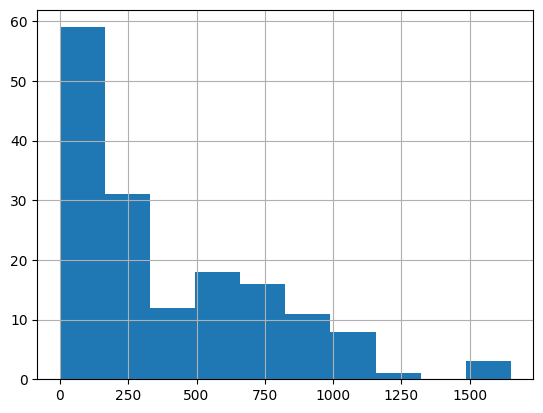

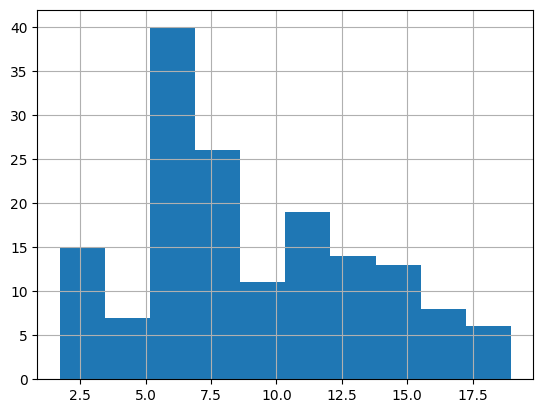

In [3]:
print(df.head())
print(df.describe())

df['Weight'].hist()
plt.show()

df['Height'].hist()
plt.show()

In [4]:
dfBream = df[df['Species'] == 'Bream']
dfBream_mW, dfBream_stdW = dfBream['Weight'].mean(), dfBream['Weight'].std()
dfBream_mH, dfBream_stdH = dfBream['Height'].mean(), dfBream['Height'].std()


newBreamWeight = np.random.normal(dfBream_mW, dfBream_stdW, 150)
newBreamHeight = np.random.normal(dfBream_mH, dfBream_stdH, 150)

newBreamHeight = np.clip(newBreamHeight, dfBream['Height'].min(), dfBream['Height'].max())
newBreamWeight = np.clip(newBreamWeight, dfBream['Weight'].min(), dfBream['Weight'].max())

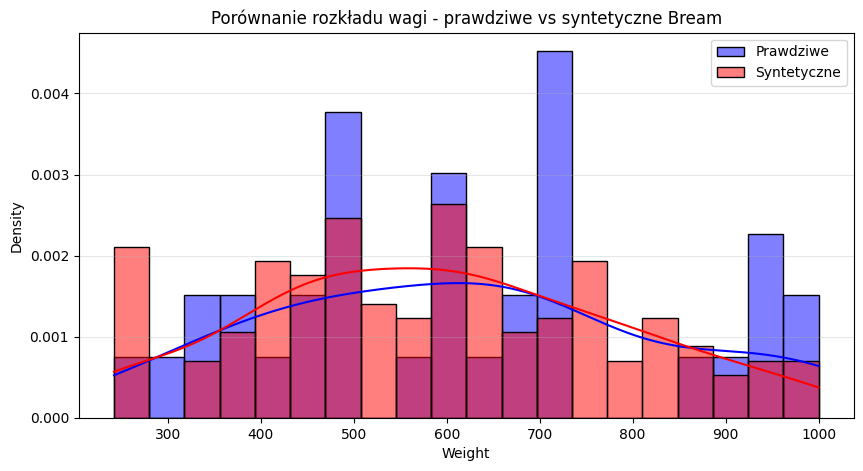

In [5]:
# Porównanie na wykresie dla wagi Bream
plt.figure(figsize=(10, 5))
sns.histplot(dfBream['Weight'], bins=20, color='blue', label='Prawdziwe', kde=True, stat='density')
sns.histplot(newBreamWeight, bins=20, color='red', label='Syntetyczne', kde=True, stat='density')

plt.title("Porównanie rozkładu wagi - prawdziwe vs syntetyczne Bream")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()